In [1]:
import os
from dotenv import load_dotenv
from openai import OpenAI
from pydantic import BaseModel
from typing import List

load_dotenv()  # Load environment variables from .env file

# Initialize client
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))


In [2]:
import pandas as pd

# ── Fallback dataset (always available) ──────────────────────────────────
FALLBACK_PRODUCTS = [
    {
        "id": 1,
        "name": "Classic White Sneakers",
        "price": 59.99,
        "category": "Footwear",
        "image_url": "https://images.unsplash.com/photo-1542291026-7eec264c27ff?w=400",
    },
    {
        "id": 2,
        "name": "Leather Crossbody Bag",
        "price": 89.99,
        "category": "Accessories",
        "image_url": "https://images.unsplash.com/photo-1548036328-c9fa89d128fa?w=400",
    },
    {
        "id": 3,
        "name": "Aviator Sunglasses",
        "price": 34.99,
        "category": "Accessories",
        "image_url": "https://images.unsplash.com/photo-1572635196237-14b3f281503f?w=400",
    },
    {
        "id": 4,
        "name": "Denim Jacket",
        "price": 74.99,
        "category": "Clothing",
        "image_url": "https://images.unsplash.com/photo-1551537482-f2075a1d41f2?w=400",
    },
    {
        "id": 5,
        "name": "Wireless Noise-Cancelling Headphones",
        "price": 129.99,
        "category": "Electronics",
        "image_url": "https://images.unsplash.com/photo-1505740420928-5e560c06d30e?w=400",
    },
]


def load_dataset_huggingface(n_samples: int = 10):
    """Try to load the HuggingFace fashion dataset. Returns a DataFrame or None."""
    try:
        from datasets import load_dataset as hf_load
        print("Attempting to load HuggingFace dataset...")
        ds = hf_load("ashraq/fashion-product-images-small", split=f"train[:{n_samples}]")
        df = pd.DataFrame(ds)
        print(f"✓ Loaded {len(df)} products from HuggingFace.")
        return df
    except Exception as exc:
        print(f"⚠  HuggingFace load failed: {exc}")
        return None


def prepare_dataset() -> list:
    """Return a list of product dicts ready for the pipeline."""
    hf_df = load_dataset_huggingface(n_samples=5)

    if hf_df is not None and "image" in hf_df.columns:
        products = []
        for i, row in hf_df.iterrows():
            products.append({
                "id": int(row.get("id", i)),
                "name": str(row.get("productDisplayName", f"Product {i}")),
                "price": round(float(row.get("price", 49.99)), 2),
                "category": str(row.get("masterCategory", "Fashion")),
                "image_pil": row["image"],  # PIL Image object
            })
        return products

    print("Using fallback product list with Unsplash images.")
    return FALLBACK_PRODUCTS


# ── Checkpoint 2 ─────────────────────────────────────────────────────────
products = prepare_dataset()
print(f"\n✓ Dataset ready: {len(products)} products loaded.")
pd.DataFrame([{k: v for k, v in p.items() if k != "image_pil"} for p in products])


/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Attempting to load HuggingFace dataset...
✓ Loaded 5 products from HuggingFace.

✓ Dataset ready: 5 products loaded.


,id,name,price,category
0,15970,Turtle Check Men Navy Blue Shirt,49.99,Apparel
1,39386,Peter England Men Party Blue Jeans,49.99,Apparel
2,59263,Titan Women Silver Watch,49.99,Accessories
3,21379,Manchester United Men Solid Black Track Pants,49.99,Apparel
4,53759,Puma Men Grey T-shirt,49.99,Apparel


In [3]:
#!pip install datasets
from datasets import load_dataset
import requests
from PIL import Image
import pandas as pd
from pathlib import Path
 
# Load dataset from HuggingFace
print("Loading product dataset...")
try:
    # Try loading the dataset
    dataset = load_dataset("ashraq/fashion-product-images-small", split="train[:100]")  # First 100 samples
    print(f"✓ Loaded {len(dataset)} products")
    
    # Convert to pandas for easier manipulation
    products_df = pd.DataFrame(dataset)
    print(f"Dataset columns: {products_df.columns.tolist()}")
    
except Exception as e:
    print(f"⚠ Could not load HuggingFace dataset: {e}")
    print("Using local images instead...")
    
    # Alternative: Use local images
    # Create a products.json file with product information
    products_data = [
        {
            "id": 1,
            "name": "Wireless Headphones",
            "price": 79.99,
            "category": "Electronics",
            "image_path": "images/product1.jpg"
        },
        # Add more products...
    ]
    
    products_df = pd.DataFrame(products_data)
 
# Create images directory
images_dir = Path("product_images")
images_dir.mkdir(exist_ok=True)

 
print(f"\n✓ Dataset prepared!")
print(f"  Total products: {len(products_df)}")

Loading product dataset...
✓ Loaded 100 products
Dataset columns: ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'image']

✓ Dataset prepared!
  Total products: 100


### Step 3


In [4]:
import base64
import requests
from pathlib import Path
from io import BytesIO
from PIL import Image


def encode_pil_image(pil_img: Image.Image, fmt: str = "JPEG") -> str:
    """Convert a PIL Image to a base64 string."""
    buffer = BytesIO()
    pil_img.convert("RGB").save(buffer, format=fmt)
    return base64.b64encode(buffer.getvalue()).decode("utf-8")


def encode_image_from_url(url: str) -> str:
    """Download an image from a URL and return its base64 encoding."""
    response = requests.get(url, timeout=15)
    response.raise_for_status()
    return base64.b64encode(response.content).decode("utf-8")


def encode_image_from_path(path) -> str:
    """Read a local image file and return its base64 encoding."""
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")


def get_image_base64(product: dict) -> str:
    """
    Universal dispatcher: returns a base64 JPEG string for any product dict,
    regardless of whether the image comes from HuggingFace, a URL, or disk.
    """
    if "image_pil" in product:
        return encode_pil_image(product["image_pil"])
    if "image_url" in product:
        return encode_image_from_url(product["image_url"])
    if "image_path" in product:
        return encode_image_from_path(product["image_path"])
    raise ValueError(f"Product {product.get('id')} has no usable image source.")


# ── Checkpoint 3 – encode first product and show stats ───────────────────
sample_b64 = get_image_base64(products[0])
print(f"✓ Image encoded successfully.")
print(f"  Base64 length : {len(sample_b64):,} characters")
print(f"  Preview       : {sample_b64[:60]}...")


✓ Image encoded successfully.
  Base64 length : 2,388 characters
  Preview       : /9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBwcJCQgKDBQNDAsL...


preview images

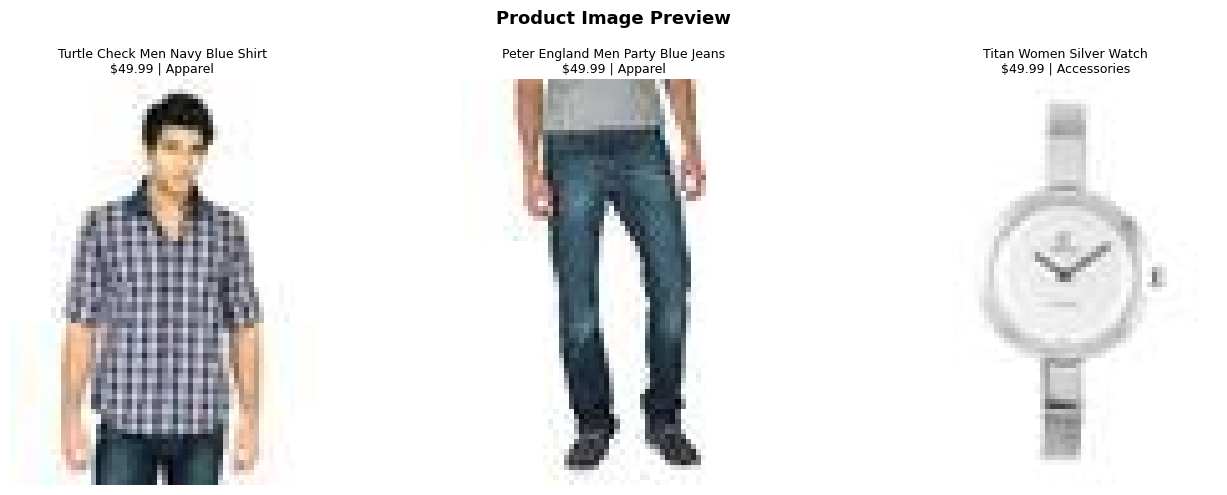

In [5]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from io import BytesIO

fig, axes = plt.subplots(1, min(3, len(products)), figsize=(14, 5))
if len(products) == 1:
    axes = [axes]

for ax, product in zip(axes, products[:3]):
    b64 = get_image_base64(product)
    img_bytes = base64.b64decode(b64)
    img = Image.open(BytesIO(img_bytes))
    ax.imshow(img)
    ax.set_title(f"{product['name']}\n${product['price']:.2f} | {product['category']}",
                 fontsize=9, wrap=True)
    ax.axis("off")

plt.suptitle("Product Image Preview", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### Step 4 Product Listing Prompt


In [6]:
def create_product_listing_prompt(
    product_name: str,
    price: float,
    category: str,
    additional_info: str = None,
) -> str:
    """
    Build the user prompt for GPT-4 Vision.

    Parameters
    ----------
    product_name    : Display name of the product
    price           : Retail price in USD
    category        : Product category (e.g. 'Electronics')
    additional_info : Optional extra details (e.g. 'Noise cancelling, 30h battery')

    Returns
    -------
    str  Fully formatted prompt string
    """
    extra = f"\n- Additional Info: {additional_info}" if additional_info else ""

    return f"""You are an expert e-commerce copywriter. Analyse the product image and create a compelling product listing.

Product Information:
- Name: {product_name}
- Price: ${price:.2f}
- Category: {category}{extra}

Please create a professional product listing that includes:

1. **Product Title** (catchy, SEO-friendly, 60 characters max)
2. **Product Description** (detailed, 150-200 words)
   - Highlight key features and benefits
   - Use persuasive language
   - Include relevant details visible in the image
3. **Key Features** (bullet points, 5-7 items)
4. **SEO Keywords** (comma-separated, 10-15 relevant keywords)

Format your response as JSON with EXACTLY this structure (no markdown fences):
{{
    "title": "Product title here",
    "description": "Full description here",
    "features": ["Feature 1", "Feature 2", "Feature 3"],
    "keywords": "keyword1, keyword2, keyword3"
}}

Be specific about what you see in the image. Mention colours, materials, design elements, and distinctive features."""


# ── Checkpoint 4 – preview the prompt ────────────────────────────────────
sample = products[0]
sample_prompt = create_product_listing_prompt(
    product_name=sample["name"],
    price=sample["price"],
    category=sample["category"],
)

print("=" * 65)
print("PROMPT PREVIEW (first product)")
print("=" * 65)
print(sample_prompt[:800] + "..." if len(sample_prompt) > 800 else sample_prompt)


PROMPT PREVIEW (first product)
You are an expert e-commerce copywriter. Analyse the product image and create a compelling product listing.

Product Information:
- Name: Turtle Check Men Navy Blue Shirt
- Price: $49.99
- Category: Apparel

Please create a professional product listing that includes:

1. **Product Title** (catchy, SEO-friendly, 60 characters max)
2. **Product Description** (detailed, 150-200 words)
   - Highlight key features and benefits
   - Use persuasive language
   - Include relevant details visible in the image
3. **Key Features** (bullet points, 5-7 items)
4. **SEO Keywords** (comma-separated, 10-15 relevant keywords)

Format your response as JSON with EXACTLY this structure (no markdown fences):
{
    "title": "Product title here",
    "description": "Full description here",
    "features": ["Featu...


### Step 5 Calling th ChatGPT API with Vision

In [7]:
import json
import time


def generate_product_listing(
    client,
    product: dict,
    model: str = "gpt-4o",   # gpt-4o has built-in vision; also works with gpt-4-turbo
    max_retries: int = 3,
    retry_delay: float = 5.0,
) -> dict:
    """
    Send a product image + prompt to GPT-4 Vision and return the parsed listing.

    Returns
    -------
    dict  Keys: title, description, features, keywords, product_id
          On failure: product_id + error
    """
    prompt    = create_product_listing_prompt(
        product["name"], product["price"], product["category"],
        product.get("additional_info"),
    )
    image_b64 = get_image_base64(product)

    messages = [{
        "role": "user",
        "content": [
            {
                "type": "image_url",
                "image_url": {
                    "url": f"data:image/jpeg;base64,{image_b64}",
                    "detail": "low",   # cheaper; switch to 'high' for fine-grained detail
                },
            },
            {
                "type": "text",
                "text": prompt,
            },
        ],
    }]

    for attempt in range(1, max_retries + 1):
        try:
            response = client.chat.completions.create(
                model=model,
                messages=messages,
                max_tokens=800,
                temperature=0.7,
            )

            raw_text = response.choices[0].message.content.strip()

            # Strip optional markdown code fences (```json ... ```)
            if raw_text.startswith("```"):
                raw_text = raw_text.split("```")[1]
                if raw_text.startswith("json"):
                    raw_text = raw_text[4:]
                raw_text = raw_text.strip()

            listing = json.loads(raw_text)
            listing["product_id"]    = product["id"]
            listing["raw_response"]  = response.choices[0].message.content
            return listing

        except json.JSONDecodeError as exc:
            print(f"  ⚠  JSON parse error (attempt {attempt}/{max_retries}): {exc}")
            if attempt == max_retries:
                return {"product_id": product["id"], "error": "JSON parse failed",
                        "raw_response": raw_text}
            time.sleep(retry_delay)

        except Exception as exc:
            print(f"  ⚠  API error (attempt {attempt}/{max_retries}): {exc}")
            if attempt == max_retries:
                return {"product_id": product["id"], "error": str(exc)}
            time.sleep(retry_delay * attempt)   # exponential back-off

    return {"product_id": product["id"], "error": "Max retries exceeded"}


# ── Checkpoint 5 – test on a single product ──────────────────────────────
print(f"Testing API with: {products[0]['name']}")
print("-" * 50)

single_result = generate_product_listing(client, products[0])

if "error" in single_result:
    print(f"✗ Error: {single_result['error']}")
else:
    print(f"✓ Title       : {single_result.get('title')}")
    print(f"  Description : {single_result.get('description', '')[:120]}...")
    print(f"  Features    : {single_result.get('features', [])[:2]} ...")
    print(f"  Keywords    : {single_result.get('keywords', '')[:80]}...")


Testing API with: Turtle Check Men Navy Blue Shirt
--------------------------------------------------
✓ Title       : Stylish Turtle Check Navy Blue Men's Shirt
  Description : Elevate your wardrobe with the Turtle Check Men Navy Blue Shirt, a perfect blend of style and comfort. This shirt featur...
  Features    : ['Classic navy blue check pattern', 'Comfortable and durable fabric'] ...
  Keywords    : men's shirt, navy blue shirt, check pattern, casual shirt, semi-formal shirt, me...


### Step 6: Processing Multiple Products


In [8]:
def batch_generate_listings(
    client,
    products: list,
    output_path="product_listing_generator.json",
    delay_between_requests: float = 1.5,
) -> list:
    """
    Generate listings for all products and save results to JSON.

    Parameters
    ----------
    client                   : Authenticated OpenAI client
    products                 : List of product dicts
    output_path              : Destination JSON file
    delay_between_requests   : Seconds between API calls (rate-limit courtesy)

    Returns
    -------
    list  All generated listings (including error records)
    """
    output_path = Path(output_path)
    results     = []
    successful  = 0
    failed      = 0

    print(f"\n{'='*60}")
    print(f"BATCH PROCESSING – {len(products)} products")
    print(f"{'='*60}")

    for idx, product in enumerate(products, start=1):
        print(f"\n[{idx}/{len(products)}] {product['name']}")
        listing = generate_product_listing(client, product)

        if "error" in listing:
            print(f"  ✗ Failed  : {listing['error']}")
            failed += 1
        else:
            print(f"  ✓ Title   : {listing.get('title', 'N/A')[:60]}")
            successful += 1

        results.append(listing)

        # Persist after every product
        output_path.write_text(json.dumps(results, indent=2, ensure_ascii=False))

        if idx < len(products):
            time.sleep(delay_between_requests)

    print(f"\n{'='*60}")
    print(f"BATCH COMPLETE")
    print(f"  Successful : {successful}")
    print(f"  Failed     : {failed}")
    print(f"  Saved to   : {output_path.resolve()}")
    print(f"{'='*60}\n")

    return results


# ── Run batch (first 3 products to limit cost during testing) ─────────────
# Remove [:3] to process all products
test_products = products[:3]

all_results = batch_generate_listings(
    client=client,
    products=test_products,
    output_path="product_listing_generator.json",
)



BATCH PROCESSING – 3 products

[1/3] Turtle Check Men Navy Blue Shirt
  ✓ Title   : Stylish Turtle Check Navy Blue Men's Shirt - Casual & Chic

[2/3] Peter England Men Party Blue Jeans
  ✓ Title   : Stylish Peter England Party Blue Jeans for Men

[3/3] Titan Women Silver Watch
  ✓ Title   : Elegant Titan Women's Silver Watch - Timeless Style

BATCH COMPLETE
  Successful : 3
  Failed     : 0
  Saved to   : /Users/markusvonaschoff/Desktop/ironhack_Bootcamp/Week 1/Lab 4/product_listing_generator.json

